# Module 06 - Next-Token Prediction

Use this notebook as the working space for the Module 06 exercises. Keep `notebooks/clean/` pristine; work in the copy created under `notebooks/solutions/`.

In [1]:
from __future__ import annotations

import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

import g2c
from g2c.lm import (
    CountsBigramLM,
    MLPLanguageModel,
    NeuralBigramLM,
    get_batch,
    perplexity,
    sample,
    train_lm,
)
from g2c.tokenizer import BPETokenizer

_ = torch.manual_seed(0)
repo_root = Path(g2c.__file__).resolve().parents[1]

## Before the Notebook

Use the tests to implement the Module 06 library pieces first. The notebook assumes `CountsBigramLM`, `NeuralBigramLM`, `MLPLanguageModel`, `perplexity`, `sample`, and `train_lm` become available as you progress through `tests/test_lm.py`. The corpus comparison later also assumes your Module 04 tokenizer works.

In [2]:
"Run from the terminal: .venv/bin/python -m pytest tests/test_lm.py -x"
"Question: Which Module 06 test is the next one failing, and what implementation does it point at?"
"Answer: "

'Answer: '

In [3]:
test_path = repo_root / "tests" / "test_lm.py"
assert test_path.exists(), f"Could not find {test_path}"

result = subprocess.run(
    [sys.executable, "-m", "pytest", str(test_path), "-q"],
    cwd=repo_root,
    text=True,
    capture_output=True,
)

print(result.stdout)
if result.stderr:
    print(result.stderr)

assert result.returncode == 0, "Module 06 language-model tests are not passing yet."
print("Module 06 language-model tests passed.")

................................................                         [100%]

Module 06 language-model tests passed.


## Exercise 1 - Context Windows and Targets

Language modeling turns one token stream into many supervised examples. Each context window predicts the token immediately after it.

In [4]:
"Question: For ids [4, 7, 1, 3, 9] and context_length=2, what are all possible (context, target) examples?"
"Answer: [([4,7], 1), ([7,1], 3), ([1,3], 9)]"

"Question: Why is this called self-supervised data rather than manually labeled data?"
"Answer: Because the target is just the next token in the corpus itself, there is no external target or Y data. Just the data going into the training corpus"

"Question: What shapes should get_batch return for batch_size=4 and context_length=3?"
"Answer: (4,3)"

'Answer: (4,3)'

In [5]:
toy_ids = torch.tensor([4, 7, 1, 3, 9])
context_length = 2

print("All deterministic windows:")
for i in range(len(toy_ids) - context_length):
    context = toy_ids[i : i + context_length].tolist()
    target = toy_ids[i + context_length].item()
    print(f"  {context} -> {target}")

x_batch, y_batch = get_batch(
    torch.arange(20),
    context_length=3,
    batch_size=4,
    generator=torch.Generator().manual_seed(0),
)
print("\nRandom batch contexts:")
print(x_batch)
print("targets:", y_batch.tolist())
assert x_batch.shape == (4, 3)
assert y_batch.shape == (4,)

All deterministic windows:
  [4, 7] -> 1
  [7, 1] -> 3
  [1, 3] -> 9

Random batch contexts:
tensor([[ 7,  8,  9],
        [ 3,  4,  5],
        [12, 13, 14],
        [16, 17, 18]])
targets: [10, 6, 15, 19]


## Exercise 2 - Counts Bigram Model

A counts bigram model learns `P(next | previous)` by tallying adjacent token pairs. No gradients, no hidden layers, just a table.

In [6]:
"Question: In [0, 1, 0, 1, 2], what should counts[0, 1] be? What should counts[1, 0] be?"
"Answer: 2 and 1 resepctively"

"Question: Why does add-one smoothing prevent unseen next tokens from getting probability zero?"
"Answer: Because to avoid invalid log values on the logit, we add 1 to every count value"

"Question: Why does CountsBigramLM.logits return log-probabilities instead of raw counts?"
"Answer: Because perplexity cares about log-probabilities"

'Answer: Because perplexity cares about log-probabilities'

In [7]:
labels = {0: "A", 1: "B", 2: "C", 3: "D"}
tiny_stream = torch.tensor([0, 1, 0, 1, 2, 1, 0, 1])

counts_lm = CountsBigramLM(vocab_size=4, smoothing=1.0)
counts_lm.fit(tiny_stream)

print("Raw counts table: rows are previous tokens, columns are next tokens")
print("      ", "  ".join(labels[i] for i in range(4)))
for prev in range(4):
    row = "  ".join(f"{counts_lm.counts[prev, nxt].item():2d}" for nxt in range(4))
    print(f"prev {labels[prev]}  {row}")

ctx = torch.tensor([0, 1, 2, 3])
probs = counts_lm.logits(ctx).exp()
print("\nSmoothed next-token probabilities:")
for prev, row in zip(ctx.tolist(), probs):
    formatted = ", ".join(f"P({labels[nxt]}|{labels[prev]})={row[nxt].item():.3f}" for nxt in range(4))
    print(formatted)

Raw counts table: rows are previous tokens, columns are next tokens
       A  B  C  D
prev A   0   3   0   0
prev B   2   0   1   0
prev C   0   1   0   0
prev D   0   0   0   0

Smoothed next-token probabilities:
P(A|A)=0.143, P(B|A)=0.571, P(C|A)=0.143, P(D|A)=0.143
P(A|B)=0.429, P(B|B)=0.143, P(C|B)=0.286, P(D|B)=0.143
P(A|C)=0.200, P(B|C)=0.400, P(C|C)=0.200, P(D|C)=0.200
P(A|D)=0.250, P(B|D)=0.250, P(C|D)=0.250, P(D|D)=0.250


## Exercise 3 - Neural Bigram and MLP Shapes

The neural bigram and MLP share the same output contract: logits shaped `(batch, vocab_size)`. The MLP differs by preserving a multi-token context through concatenation.

In [8]:
"Question: Why does NeuralBigramLM need to squeeze a context shaped (B, 1) before embedding?"
"Answer: Because we want embed to return a 2-shape and not a 3-shape result"

"Question: If an MLP has context_length=3 and embedding_dim=8, what is the flattened hidden-layer input width?"
"Answer: 24. Three previous tokens times eight embeddings for each token"

"Question: Why does concatenating embeddings preserve order while averaging them does not?"
"Answer: Because averaging is a commutative and concatenating is not"

'Answer: Because averaging is a commutative and concatenating is not'

In [9]:
neural_bigram = NeuralBigramLM(vocab_size=10, embedding_dim=4)
bigram_ctx = torch.tensor([[0], [1], [2]])
bigram_logits = neural_bigram(bigram_ctx)
print("neural bigram context:", tuple(bigram_ctx.shape))
print("neural bigram logits:", tuple(bigram_logits.shape))

mlp = MLPLanguageModel(vocab_size=10, context_length=2, embedding_dim=4, hidden_dim=8)
ctx_ab = torch.tensor([[3, 7]])
ctx_ba = torch.tensor([[7, 3]])
logits_ab = mlp(ctx_ab)
logits_ba = mlp(ctx_ba)
max_difference = (logits_ab - logits_ba).abs().max().item()
print("\nMLP context shape:", tuple(ctx_ab.shape))
print("MLP logits shape:", tuple(logits_ab.shape))
print(f"max logit difference between [3, 7] and [7, 3]: {max_difference:.6f}")
assert bigram_logits.shape == (3, 10)
assert logits_ab.shape == logits_ba.shape == (1, 10)
assert max_difference > 1e-3

neural bigram context: (3, 1)
neural bigram logits: (3, 10)

MLP context shape: (1, 2)
MLP logits shape: (1, 10)
max logit difference between [3, 7] and [7, 3]: 0.123580


## Exercise 4 - Perplexity and Autoregressive Sampling

Perplexity evaluates the model on known text. Sampling generates unknown text by repeatedly predicting and appending one token.

In [10]:
"Question: Why should a uniform model over V tokens have perplexity V?"
"Answer: Because perplexity is defined as the uniform log probabilities for V elements"

"Question: Why does a perfect deterministic model have perplexity 1?"
"Answer: Because there's essentially only one plausible answer each time"

"Question: During sampling, why do we feed the newly sampled token back into the next context?"
"Answer: Because this is how auto regression generates a sequence of tokens and not just the next token"

'Answer: Because this is how auto regression generates a sequence of tokens and not just the next token'

In [4]:
uniform_counts = CountsBigramLM(vocab_size=8, smoothing=1.0)
uniform_eval_ids = torch.randint(0, 8, (200,), generator=torch.Generator().manual_seed(1))
uniform_ppl = perplexity(uniform_counts, uniform_eval_ids)
print(f"uniform counts perplexity: {uniform_ppl:.3f}")

deterministic_counts = CountsBigramLM(vocab_size=2, smoothing=0.0)
deterministic_counts.fit(torch.tensor([0, 1] * 100))
deterministic_eval_ids = torch.tensor([0, 1] * 20)
deterministic_ppl = perplexity(deterministic_counts, deterministic_eval_ids)
generated = sample(
    deterministic_counts,
    prompt_ids=torch.tensor([0]),
    num_tokens=12,
    generator=torch.Generator().manual_seed(0),
)
print(f"deterministic counts perplexity: {deterministic_ppl:.3f}")
print("sampled deterministic pattern:", generated.tolist())
assert abs(uniform_ppl - 8.0) < 1e-3
assert abs(deterministic_ppl - 1.0) < 1e-3

uniform counts perplexity: 8.000
deterministic counts perplexity: 1.000
sampled deterministic pattern: [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]


## Exercise 5 - Train Three Language Models on One Corpus

Use the same token stream for all three models so the perplexity comparison is fair. `./setup.sh` prepares `data/tinyshakespeare.txt`; the built-in text is only a fallback if that file is missing.

In [5]:
"Question: Why must the counts bigram, neural bigram, and MLP be evaluated on the same token stream?"
"Answer: Because otherwise their comparisons would be apples to oranges"

"Question: What do you expect to happen to validation perplexity as the model gets more context?"
"Answer: It should decrease because the additional features should improve the fit"

"Question: Why can validation perplexity stop improving even while training loss keeps falling?"
"Answer: Because past a certain point additional training steps are overfitting, just capturing variance in the sample rather than actual structure of the distrubtion"

'Answer: Because past a certain point additional training steps are overfitting, just capturing variance in the sample rather than actual structure of the distrubtion'

In [2]:
def load_language_modeling_text() -> str:
    tiny_shakespeare = repo_root / "data" / "tinyshakespeare.txt"
    if tiny_shakespeare.exists():
        print(f"Using {tiny_shakespeare.relative_to(repo_root)}")
        return tiny_shakespeare.read_text(encoding="utf-8")

    print("Using built-in tiny corpus. Run ./setup.sh to download data/tinyshakespeare.txt.")
    base = """
    the model predicts the next token from the context
    the context helps the model choose a better next token
    the king speaks to the queen in the hall
    the queen answers the king with a careful word
    the student trains a small language model
    the small language model learns short repeated patterns
    gradients update embeddings and linear weights
    sampling repeats predict append and predict again
    """
    return ("\n".join(line.strip() for line in base.strip().splitlines()) + "\n") * 80


text = load_language_modeling_text()
tokenizer = BPETokenizer()
target_vocab_size = 1024
tokenizer.train(text, vocab_size=target_vocab_size)
ids = torch.tensor(tokenizer.encode(text), dtype=torch.long)
vocab_size = len(tokenizer.vocab)
split = int(0.9 * len(ids))
train_ids = ids[:split]
val_ids = ids[split:]

print("characters:", len(text))
print("tokens:", len(ids))
print("vocab size:", vocab_size)
print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))
assert len(val_ids) > 10

Using data/tinyshakespeare.txt
1087751
1065012
1048504
1033140
1018975
1004877
992147
980376
969770
959487
949290
940528
932070
923936
916368
909272
902191
895529
889094
882737
876682
871181
866163
861250
856372
851723
847516
843417
839449
835485
831542
827636
823782
819946
816278
812618
809004
805880
802906
799939
796978
794123
791367
788667
785969
783319
780728
778307
775910
773537
771179
768823
766577
764413
762288
760164
758059
755967
753886
751809
749739
747714
745733
743756
741815
739919
738072
736256
734455
732688
730925
729176
727451
725763
724096
722438
720804
719172
717610
716050
714495
712950
711456
709962
708483
707023
705579
704145
702748
701363
699982
698608
697235
695868
694529
693216
691921
690627
689333
688066
686808
685568
684338
683110
681884
680662
679441
678228
677022
675827
674654
673487
672354
671223
670096
668972
667856
666743
665645
664554
663466
662380
661299
660221
659144
658083
657026
655980
654954
653929
652907
651891
650909
649927
648949
647977
647006
6460

model              validation perplexity
----------------------------------------
counts bigram         146.925
neural bigram         137.710
MLP context=3         115.553


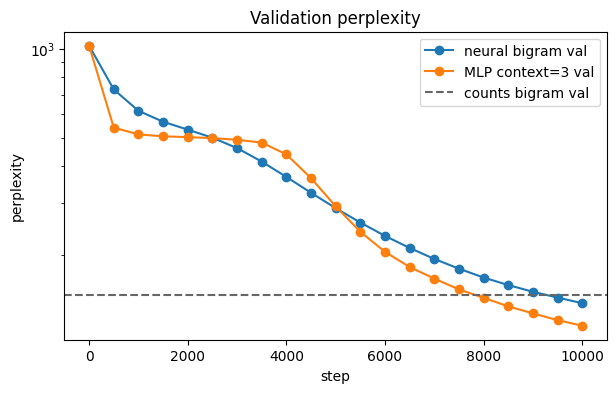

In [23]:
num_steps = 10000
log_every = 500

counts_model = CountsBigramLM(vocab_size=vocab_size, smoothing=1.0)
counts_model.fit(train_ids)
counts_ppl = perplexity(counts_model, val_ids)

neural_model = NeuralBigramLM(vocab_size=vocab_size, embedding_dim=128)
neural_history = train_lm(
    neural_model,
    train_ids,
    val_ids=val_ids,
    batch_size=256,
    num_steps=num_steps,
    lr=0.4,
    log_every=log_every,
    generator=torch.Generator().manual_seed(1),
)

mlp_model = MLPLanguageModel(
    vocab_size=vocab_size,
    context_length=3,
    embedding_dim=128,
    hidden_dim=512,
)
mlp_history = train_lm(
    mlp_model,
    train_ids,
    val_ids=val_ids,
    batch_size=256,
    num_steps=num_steps,
    lr=0.2,
    log_every=log_every,
    generator=torch.Generator().manual_seed(2),
)

results = [
    ("counts bigram", counts_ppl),
    ("neural bigram", neural_history["val_perplexities"][-1]),
    ("MLP context=3", mlp_history["val_perplexities"][-1]),
]

print("model              validation perplexity")
print("-" * 40)
for name, ppl in results:
    print(f"{name:18s} {ppl:10.3f}")

train_steps = list(range(0, num_steps, log_every))
if train_steps[-1] != num_steps - 1:
    train_steps.append(num_steps - 1)

plt.figure(figsize=(7, 4))
plt.plot(train_steps, neural_history["val_perplexities"], marker="o", label="neural bigram val")
plt.plot(train_steps, mlp_history["val_perplexities"], marker="o", label="MLP context=3 val")
plt.axhline(counts_ppl, color="0.4", linestyle="--", label="counts bigram val")
plt.yscale("log")
plt.title("Validation perplexity")
plt.xlabel("step")
plt.ylabel("perplexity")
plt.legend()
plt.show()

## Exercise 6 - Sample From Each Model

Generation is the same next-token prediction loop run repeatedly. The text will be rough; the goal is to compare failure modes. The sampling cell uses a deliberately conservative display sampler: it masks out token IDs that never occurred in training, keeps only the top few candidates, and uses a low temperature so byte-level BPE noise does not dominate the comparison.

In [19]:
"Question: Which model's sample has the most locally plausible text? What evidence do you see?"
"Answer: MLP by far, because it's perplexity is much lower"

"Question: What kinds of repetition or incoherence show up even in the best sample?"
"Answer: The sequence getting stuck in a loop"

"Question: Why should none of these models produce long-range coherent prose yet?"
"Answer: Because none of them capture long range structure besides a small number of lookback tokens"

'Answer: Because none of them capture long range structure besides a small number of lookback tokens'

In [20]:
observed_token_ids = torch.unique(train_ids)
sample_prompt_text = "First Citizen:\n" if "First Citizen:" in text else "the model "


def sample_readable_tokens(
    model,
    prompt_ids: torch.Tensor,
    num_tokens: int,
    *,
    temperature: float = 0.55,
    top_k: int = 12,
    generator: torch.Generator | None = None,
) -> torch.Tensor:
    """Conservative notebook sampler for easier-to-read qualitative comparisons."""
    ctx_len = model.context_length
    out = list(prompt_ids.tolist())
    for _ in range(num_tokens):
        ctx = torch.tensor(out[-ctx_len:], dtype=torch.long).unsqueeze(0)
        logits = model.logits(ctx)[0][observed_token_ids]
        candidate_ids = observed_token_ids
        if top_k is not None and top_k < logits.numel():
            logits, top_positions = torch.topk(logits, k=top_k)
            candidate_ids = observed_token_ids[top_positions]
        logits = logits / temperature
        probs = torch.softmax(logits, dim=-1)
        sampled_index = torch.multinomial(probs, num_samples=1, generator=generator).item()
        out.append(int(candidate_ids[sampled_index].item()))
    return torch.tensor(out, dtype=prompt_ids.dtype)


def decode_sample(model_name: str, model, *, temperature: float = 0.55, top_k: int = 12) -> None:
    prompt = torch.tensor(tokenizer.encode(sample_prompt_text), dtype=torch.long)
    if prompt.shape[0] < model.context_length:
        prompt = val_ids[: model.context_length]
    generated_ids = sample_readable_tokens(
        model,
        prompt_ids=prompt,
        num_tokens=160,
        temperature=temperature,
        top_k=top_k,
        generator=torch.Generator().manual_seed(10 + model.context_length),
    )
    print(f"\n--- {model_name} ---")
    print(tokenizer.decode(generated_ids.tolist()))


decode_sample("counts bigram", counts_model)
decode_sample("neural bigram", neural_model)
decode_sample("MLP context=3", mlp_model)


--- counts bigram ---
First Citizen:
And fir, former, the kingly seen, I know you
Wellowbreamine eyes,
LAUTI broth OF YORK:
ADudoth the curderer:
I cannot bell, as we do you more than a did I knows the great you to the soulden, if you our dee that the ba bles.
Henemberland's hely s;
Norkindness hath bet's hopenempityalk, who is the crown in OF YORK:
NI bldaughter'd with suset not be sould:
WICK:
O have made 

--- neural bigram ---
First Citizen:
HAM:
Warrived with both wilday the ty insease to be goolull, that honour, to him are the slaword
That fell, that is not bother and gentlewords my weet inclack, I do you beath unfle, as hout, I know, wherefortravire and to him, that ward's s.
Norkes my ticiance;
The balt the seacher:
His the curseathing is a bo-houtrivir, the say:
His breath to h, to be 

--- MLP context=3 ---
First Citizen:
What is the gries,
Then again
Thed, with the wears
I know are the lain a may of this inflow
Let me a crop on my cuse
Sting, if the ho,
Well's gring wart's 

## Exercise 7 - Plot Training Curves

Training loss and validation perplexity tell the same story in different units. Plot both and look for a gap between fitting the training stream and generalizing to held-out text.

In [21]:
"Question: Which curve is smoother: training loss or validation perplexity? Why might that be?"
"Answer: training loss. Because training loss should always decrease on every step because it's perfectly fitting the sample, whereas validation perplexity is out-of-sample"

"Question: If validation perplexity rises while training loss falls, what does that suggest?"
"Answer: That marginal training runs are overfitting"

"Question: How would you modify the experiment to test whether more context helps?"
"Answer: Trying the run at increasing context windows and comparing validation perplexity"

'Answer: Trying the run at increasing context windows and comparing validation perplexity'

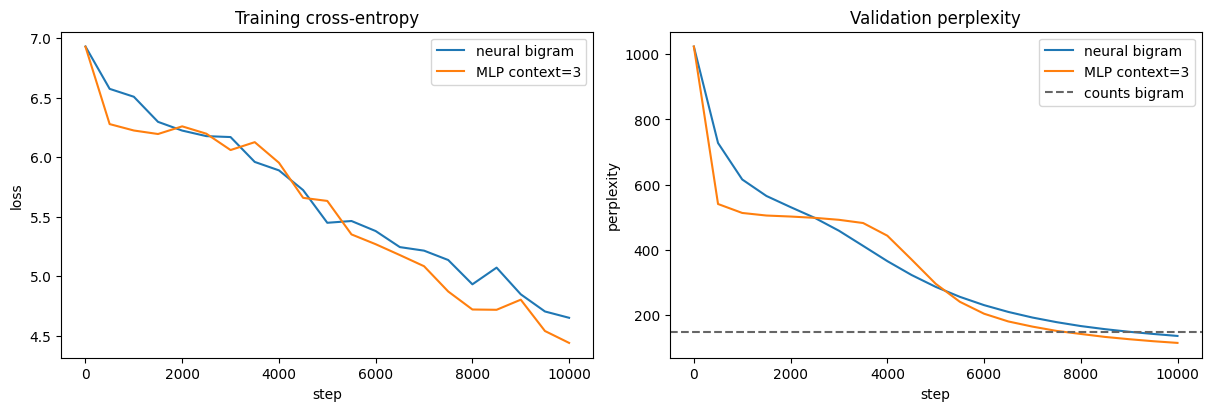

In [22]:
def logged_steps(num_steps: int, log_every: int) -> list[int]:
    steps = list(range(0, num_steps, log_every))
    final_step = num_steps - 1
    if steps[-1] != final_step:
        steps.append(final_step)
    return steps


steps = logged_steps(num_steps, log_every)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(steps, neural_history["train_losses"], label="neural bigram")
axes[0].plot(steps, mlp_history["train_losses"], label="MLP context=3")
axes[0].set_title("Training cross-entropy")
axes[0].set_xlabel("step")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(steps, neural_history["val_perplexities"], label="neural bigram")
axes[1].plot(steps, mlp_history["val_perplexities"], label="MLP context=3")
axes[1].axhline(counts_ppl, color="0.4", linestyle="--", label="counts bigram")
axes[1].set_title("Validation perplexity")
axes[1].set_xlabel("step")
axes[1].set_ylabel("perplexity")
axes[1].legend()

plt.show()